# Part 3: NLP and Sequence Modeling Mini Project

In [25]:
#Importing required libraries
import pandas as pd         
import re                    # Regular expressions for text cleaning
import numpy as np  
from collections import Counter          
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn tools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


## Task 1: Dataset Understanding

In [3]:
# Loading the dataset
df = pd.read_csv('customer_support_text_classification.csv')

print("=" * 60)
print(" BASIC INFORMATION")
print("=" * 60)
print(f"Total records    : {len(df)}")
print(f"Total columns    : {len(df.columns)}")
print(f"Column names     : {df.columns.tolist()}")
print(f"Duplicate messages: {df['customer_message'].duplicated().sum()}")
print(f"Unique messages  : {df['customer_message'].nunique()}")
print()
print("First 5 rows:")
df.head ()

 BASIC INFORMATION
Total records    : 1500
Total columns    : 6
Column names     : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']
Duplicate messages: 866
Unique messages  : 634

First 5 rows:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
# ─── Target Label Distribution ──────────────────────────────────────

print(" TARGET LABEL DISTRIBUTION")
print("-" * 40)
label_counts = df['sentiment_label'].value_counts()
print(label_counts)
print()
print("As percentages:")
print((label_counts / len(df) * 100).round(1).astype(str) + '%')

 TARGET LABEL DISTRIBUTION
----------------------------------------
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

As percentages:
sentiment_label
neutral     34.9%
negative    33.1%
positive    31.9%
Name: count, dtype: str


Data is balanced (~33% each) - that's ideal.

In [5]:
# ─── Text Length Analysis ────────────────────────────────────────────
print(" TEXT LENGTH (word count) STATISTICS")
print("-" * 40)
print(df['word_count'].describe().round(2))

 TEXT LENGTH (word count) STATISTICS
----------------------------------------
count    1500.00
mean       12.72
std         3.69
min         7.00
25%        10.00
50%        12.00
75%        15.00
max        26.00
Name: word_count, dtype: float64


In [6]:
# ─── Sample Text Records ─────────────────────────────────────────────
print("SAMPLE TEXT RECORDS")
print("-" * 60)
for label in ['positive', 'neutral', 'negative']:
    examples = df[df['sentiment_label'] == label]['customer_message'].head(2)
    print(f"\n🔵 {label.upper()}:")
    for msg in examples:
        print(f"   → {msg}")

SAMPLE TEXT RECORDS
------------------------------------------------------------

🔵 POSITIVE:
   → The refund process was fast and convenient. I appreciate the quick response.
   → I am satisfied with the plan and would recommend it to others. My ticket number is 99198.

🔵 NEUTRAL:
   → I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
   → I need information about the payment process.

🔵 NEGATIVE:
   → My refund is still pending and this experience is frustrating. My ticket number is 33927.
   → My refund is still pending and this experience is frustrating.


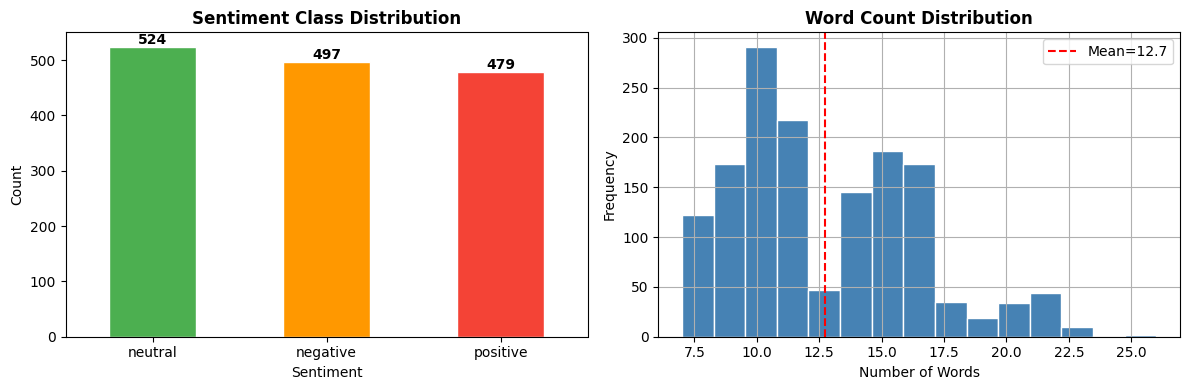

In [7]:
# ─── Visualize Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar chart
colors = ['#4CAF50', '#FF9800', '#F44336']
label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=0)
axes[0].set_title('Sentiment Class Distribution', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Word count histogram
df['word_count'].hist(bins=15, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean={df["word_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


| Insight | Value | What it means |
|---------|-------|---------------|
| Total records | 1,500 | Medium-sized dataset - good for learning |
| Unique messages | 634 | Dataset has duplicates  |
| Classes | positive / neutral / negative | 3-class classification task |
| Avg word count | ~12.7 words | Short messages  |
| Class balance | ~33% each | Balanced - accuracy is a valid metric |

> 866 messages are duplicates. This is why models achieve 100% accuracy. The same messages appear in both train and test sets. This is called **data leakage**. In real projects we always deduplicate before splitting.

## Task 2: Text Preprocessing


In [8]:
# Define Stopwords
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'he','him','his','she','her','hers','it','its','they','them','their',
    'what','which','who','this','that','these','those','am','is','are','was',
    'were','be','been','being','have','has','had','do','does','did','will',
    'would','could','should','may','might','shall','can','need','a','an','the',
    'and','but','if','or','because','as','until','while','of','at','by','for',
    'with','about','to','in','on','from','up','into','through','then','so',
    'please','ticket','number'   # domain-specific noise
}

print(f"Total stopwords: {len(STOPWORDS)}")

Total stopwords: 81


In [9]:
# Cleaning Function
def clean_text(text):
    """
    Clean a single text string.
    Returns: cleaned string (lowercased, no symbols, no stopwords)
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove everything except letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize (split into words)
    tokens = text.split()
    
    # Remove stopwords and very short words (length <= 2)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    
    # Join tokens back into a string
    return ' '.join(tokens)
    
  # ── Test on one example ──────────────────────────────────────────────
sample = "My refund is still pending and this experience is frustrating. My ticket number is 33927."
print("BEFORE:", sample)
print("AFTER :", clean_text(sample))

BEFORE: My refund is still pending and this experience is frustrating. My ticket number is 33927.
AFTER : refund still pending experience frustrating


In [10]:
# ─── Apply cleaning to whole dataset ────────
df['cleaned'] = df['customer_message'].apply(clean_text)

print("BEFORE vs AFTER CLEANING")
print("-" * 70)
for i in range(5):
    print(f"[{df['sentiment_label'].iloc[i].upper():8}]")
    print(f"  Original : {df['customer_message'].iloc[i]}")
    print(f"  Cleaned  : {df['cleaned'].iloc[i]}")
    print()

BEFORE vs AFTER CLEANING
----------------------------------------------------------------------
[NEUTRAL ]
  Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  Cleaned  : information payment process respond soon possible

[NEUTRAL ]
  Original : I need information about the payment process.
  Cleaned  : information payment process

[POSITIVE]
  Original : The refund process was fast and convenient. I appreciate the quick response.
  Cleaned  : refund process fast convenient appreciate quick response

[NEGATIVE]
  Original : My refund is still pending and this experience is frustrating. My ticket number is 33927.
  Cleaned  : refund still pending experience frustrating

[NEUTRAL ]
  Original : Please tell me how to update my account details.
  Cleaned  : tell how update account details



## Task 3: Text Vectorization

In [11]:
# ─── Train-Test Split ────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned'],           # Input: cleaned text
    df['sentiment_label'],   # Target: sentiment label
    test_size=0.2,           # 20% goes to test
    random_state=42,         # For reproducibility (same split every run)
    stratify=df['sentiment_label']  # Balanced classes in both sets
)

print(f"Training samples : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test samples     : {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Training samples : 1200 (80%)
Test samples     : 300 (20%)

Train label distribution:
sentiment_label
neutral     419
negative    398
positive    383
Name: count, dtype: int64

Test label distribution:
sentiment_label
neutral     105
negative     99
positive     96
Name: count, dtype: int64


In [12]:
# ─── METHOD 1: Bag of Words ─────────────────────────────────
bow_vectorizer = CountVectorizer(
    max_features=500    # Only keep the 500 most common words (vocabulary size)
                        # Helps control memory and reduce noise
)

# fit_transform() = learn vocabulary from train data + convert to numbers
X_train_bow = bow_vectorizer.fit_transform(X_train)

# transform() = only convert (vocabulary already learned )
X_test_bow  = bow_vectorizer.transform(X_test)

print(" BAG OF WORDS")
print(f"Vocabulary size   : {len(bow_vectorizer.vocabulary_)} words")
print(f"Train matrix shape: {X_train_bow.shape}")
print(f"  → {X_train_bow.shape[0]} messages × {X_train_bow.shape[1]} unique words")
print()
print("First 20 vocabulary words:")
print(bow_vectorizer.get_feature_names_out()[:20].tolist())

 BAG OF WORDS
Vocabulary size   : 149 words
Train matrix shape: (1200, 149)
  → 1200 messages × 149 unique words

First 20 vocabulary words:
['account', 'activate', 'after', 'ago', 'analytics', 'any', 'app', 'appreciate', 'arrived', 'assigned', 'available', 'bad', 'between', 'billing', 'call', 'cancel', 'care', 'charged', 'checking', 'clear']


In [13]:
# ─── Show BoW vector for one message ────────────────────────────────
# Let's visualize a BoW vector 

sample_msg = X_train.iloc[0]
sample_vec = X_train_bow[0].toarray()[0]  # Convert sparse matrix to array

print(f"Message: '{sample_msg}'")
print()
print("Non-zero entries in its BoW vector:")
vocab = bow_vectorizer.get_feature_names_out()
for idx, count in enumerate(sample_vec):
    if count > 0:
        print(f"  '{vocab[idx]}' → {int(count)}")


Message: 'confirm whether assigned respond soon possible'

Non-zero entries in its BoW vector:
  'assigned' → 1
  'confirm' → 1
  'possible' → 1
  'respond' → 1
  'soon' → 1
  'whether' → 1


In [26]:
# ─── METHOD 2: TF-IDF ────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)   
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(" TF-IDF")
print(f"Train matrix shape: {X_train_tfidf.shape}")
print()

# Show TF-IDF scores for one message
sample_vec_tfidf = X_train_tfidf[0].toarray()[0]
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()
print(f"TF-IDF values for: '{X_train.iloc[0]}'")
print()
for idx, score in enumerate(sample_vec_tfidf):
    if score > 0:
        print(f"  '{vocab_tfidf[idx]}' → {score:.4f}")

 TF-IDF
Train matrix shape: (1200, 391)

TF-IDF values for: 'confirm whether assigned respond soon possible'

  'assigned' → 0.3364
  'assigned respond' → 0.4339
  'confirm' → 0.3364
  'confirm whether' → 0.3364
  'possible' → 0.2217
  'respond' → 0.2217
  'respond soon' → 0.2217
  'soon' → 0.2217
  'soon possible' → 0.2217
  'whether' → 0.3364
  'whether assigned' → 0.3364


- Both BoW and TF-IDF are **bag** methods - they ignore word order.

#### Explain why text must be converted into vectors before being used by a model.

Machine learning models are fundamentally mathematical systems — they perform operations such as multiplication, addition, and differentiation. These operations can only be applied to **numbers**, not to raw text.

A word like `"frustrating"` has no inherent numerical value a computer can compute with. Before any model whether Logistic Regression, Naive Bayes, or an LSTM can process a customer message, every word must be represented as a number or a list of numbers called a **vector**.

This conversion process is called **vectorization**, and it serves three purposes:

**1. Mathematical compatibility**
Models learn by adjusting weights through equations. A sentence must become a fixed-size numerical array before it can pass through any such equation. For example, after TF-IDF vectorization, the message `"refund still pending frustrating"` becomes a 500-dimensional vector like `[0, 0, 0.43, 0, 0.61, ...]` — one value per vocabulary word.

**2. Capturing word importance**
Raw text treats all words as equal symbols. Vectors encode meaning quantitatively. TF-IDF, for instance, assigns a higher value to `"frustrating"` (rare but meaningful) than to `"the"` (common, meaningless for sentiment) giving the model a better signal to learn from.

**3. Uniform input size**
Models require all inputs to be the same shape. Customer messages in this dataset range from 7 to 26 words. Vectorization (via fixed vocabulary size in BoW/TF-IDF, or padding in sequence models) standardises every message into an identical-length numerical array, regardless of its original length.

---

> In short: text is human-readable but mathematically meaningless. Vectors are the bridge that translates language into a form a model can learn from.

## Task 4: Baseline Model

In [27]:
# ─── Model 1: Naive Bayes with Bag of Words ──────────────────────────

nb_model = MultinomialNB()         # MultinomialNB works with count-based data (BoW)
nb_model.fit(X_train_bow, y_train) # Learn from training data
y_pred_nb = nb_model.predict(X_test_bow)  # Predict on unseen test data

print("=" * 60)
print("MODEL 1: Naive Bayes (Bag of Words)")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print()
print("Detailed Report:")
print(classification_report(y_test, y_pred_nb))

MODEL 1: Naive Bayes (Bag of Words)

Accuracy: 1.0000

Detailed Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [28]:
# ─── Model 2: Logistic Regression with TF-IDF ───────────────────────

lr_model = LogisticRegression(
    max_iter=1000,      # Max iterations for the solver to converge
    random_state=42,    # Reproducibility
    C=1.0               # Regularization strength (lower = stronger regularization)
                        # Regularization prevents overfitting
)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("=" * 60)
print("= MODEL 2: Logistic Regression (TF-IDF)")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print("Detailed Report:")
print(classification_report(y_test, y_pred_lr))

= MODEL 2: Logistic Regression (TF-IDF)

Accuracy: 1.0000

Detailed Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



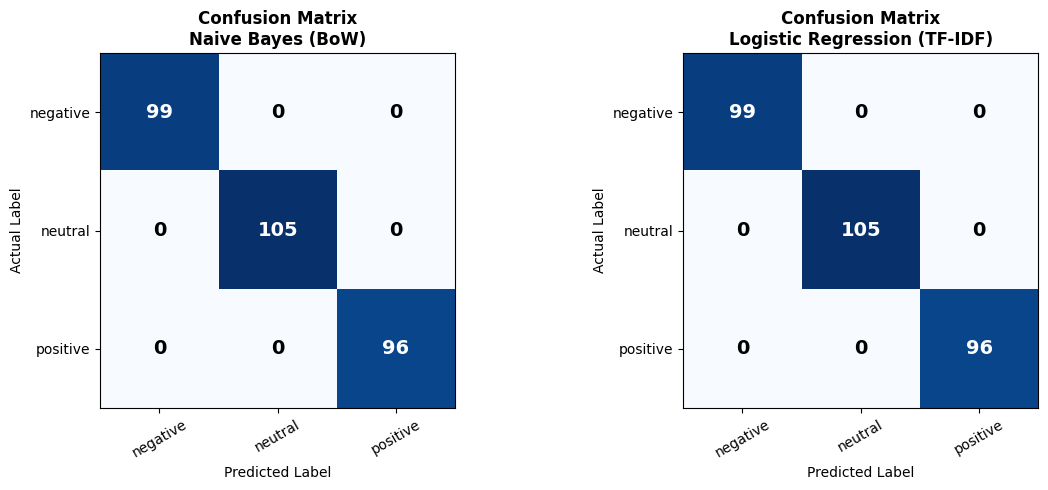

In [17]:
# ─── Confusion Matrix Visualization ─────────────────────────────────

classes = ['negative', 'neutral', 'positive']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_nb, y_pred_lr],
                              ['Naive Bayes (BoW)', 'Logistic Regression (TF-IDF)']):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(classes, rotation=30)
    ax.set_yticklabels(classes)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                   color='white' if cm[i,j] > cm.max()*0.5 else 'black',
                   fontsize=14, fontweight='bold')
            
plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ─── Top Predictive Words (LR Interpretability) ──────────────────────

print("TOP WORDS PER CLASS (Logistic Regression)")
print("-" * 50)
feature_names = tfidf_vectorizer.get_feature_names_out()
for i, class_name in enumerate(lr_model.classes_):
    top_indices = lr_model.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"\n{class_name.upper():10}: {', '.join(top_words)}")

# These are the words with highest coefficients for each class.
# This is called model interpretability.

TOP WORDS PER CLASS (Logistic Regression)
--------------------------------------------------

NEGATIVE  : not, bad regret, bad, quality bad, purchasing, regret, regret purchasing, crashes, crashes whenever, try

NEUTRAL   : status, request, share status, share, plans, steps, steps activate, provide, activate, provide steps

POSITIVE  : team, smooth, response, support team, easy use, easy, new, like new, fast convenient, fast


In [30]:
# ─── Save Sample Predictions ─────────────────────────────────────────
import os
os.makedirs('results', exist_ok=True)

results_df = pd.DataFrame({
                'message': X_test.values,
                'true_label': y_test.values,
                'pred_naive_bayes': y_pred_nb,
                'pred_logistic_reg': y_pred_lr
            })
results_df['nb_correct'] = results_df['true_label'] == results_df['pred_naive_bayes']
results_df['lr_correct'] = results_df['true_label'] == results_df['pred_logistic_reg']
results_df.to_csv('results/model_evaluation.csv', index=False)

with open('results/sample_predictions.txt', 'w', encoding='utf-8') as f:
    f.write("SAMPLE PREDICTIONS – Part 3 NLP Pipeline\n")
    f.write("=" * 60 + "\n\n")
    for model_name, pred_col in [("Naive Bayes (BoW)", "pred_naive_bayes"),
                                              ("Logistic Regression (TF-IDF)", "pred_logistic_reg")]:
        f.write(f"=== {model_name} ===\n")
        for i in range(15):
             row = results_df.iloc[i]
             correct = "✓" if row['true_label'] == row[pred_col] else "✗"
             f.write(f"{correct} Message   : {row['message']}\n")
             f.write(f"  True      : {row['true_label']}\n")
             f.write(f"  Predicted : {row[pred_col]}\n\n")
        f.write("\n")

print("Results saved")
print("   - model_evaluation.csv")
print("   - sample_predictions.txt")

Results saved
   - model_evaluation.csv
   - sample_predictions.txt


#### ⚠️ Note on 100% Accuracy

Both models show **100% accuracy** on this dataset. But this not a positive indicator because:

1. **Data Leakage**: The dataset has 1,500 rows but only 634 unique messages. The same messages appear in both train and test sets, so the model has already "seen" the answers.

2. **Simple vocabulary**: Negative messages consistently use words like `"frustrating"`, `"terrible"`, while positive ones use `"appreciate"`, `"excellent"`. The patterns are very obvious.

**In a real project:**
- Always `drop_duplicates()` before splitting
- Use cross-validation for more honest evaluation
- Look at errors - models are usually 75-90% accurate on real messy text

## Task 5: Sequence Model or Conceptual Architecture


### How a Sequence Model Processes Text

```
"refund was fast"
      ↓
Tokenize → ["refund", "was", "fast"]
      ↓
Index  →   [45, 12, 67]          (each word gets a number ID)
      ↓
Embed  →   [[0.2, 0.8, ...], ...]  (each ID → dense vector)
      ↓
LSTM   →   hidden state (memory of the sequence)
      ↓
Dense  →   [0.1, 0.7, 0.2]       (probabilities for each class)
      ↓
Output → "positive"
```

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=500, oov_token='<OOV>')
#n um_words = vocabulary size
# oov_token = token for Out-Of-Vocabulary words (words not seen in training)

tokenizer.fit_on_texts(X_train)  # Build vocabulary from training text
X_train_seq = tokenizer.texts_to_sequences(X_train)  # Convert to sequences
X_test_seq  = tokenizer.texts_to_sequences(X_test)

### LSTM Architecture Design


```
INPUT SEQUENCE  [45, 12, 67, 23, 0, 0, ..., 0]   (30 word indices)
      ↓
EMBEDDING LAYER  vocab_size=500, embedding_dim=64
   Converts each word index into a 64-dimensional dense vector.
   Example: index 45 → [0.21, -0.13, 0.87, ...] (64 numbers)
   The model LEARNS these vectors during training.
   Output shape: (batch, 30, 64)
      ↓
LSTM LAYER  units=64
   Reads the sequence step by step (word by word).
   At each step, it maintains a 'hidden state' (memory).
   The hidden state carries context from previous words.
   Output shape: (batch, 64)  ← final hidden state
      ↓
DROPOUT LAYER  rate=0.3
   Randomly turns off 30% of neurons during training.
   Prevents overfitting (memorizing training data).
      ↓
DENSE LAYER  units=3, activation='softmax'
   3 units = 3 output classes (positive, neutral, negative)
   Softmax turns scores into probabilities that sum to 1.
   Output: [0.05, 0.10, 0.85] → predicted class = 'negative'

LOSS FUNCTION: categorical_crossentropy
   Measures how wrong the predictions are. Model minimizes this.
   
OPTIMIZER: Adam
   Adjusts weights to reduce the loss. The learning algorithm.
   
METRIC: accuracy
```

In [34]:

# ── Step 1: Build vocabulary ─────────────────────────────────────────
all_words = []
for text in X_train:
    all_words.extend(text.split())

word_freq = Counter(all_words)
vocab = ['<PAD>', '<OOV>'] + [w for w, _ in word_freq.most_common(498)]
word2idx = {word: idx for idx, word in enumerate(vocab)}

# ── Step 2: Sequence conversion function ─────────────────────────────
def text_to_sequence(text, word2idx, max_len=30):
    tokens = text.split()
    seq = [word2idx.get(t, 1) for t in tokens]   # 1 = <OOV>
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))    # pad with 0 = <PAD>
    else:
        seq = seq[:max_len]                        # truncate
    return seq

MAX_LEN = 30

# ── Step 3: Convert to NumPy arrays ──────────────────────
X_train_seq = np.array([text_to_sequence(t, word2idx, MAX_LEN) for t in X_train])
X_test_seq  = np.array([text_to_sequence(t, word2idx, MAX_LEN) for t in X_test])

print(f"X_train_seq type : {type(X_train_seq)}")   # <class 'numpy.ndarray'>
print(f"X_train_seq shape: {X_train_seq.shape}")    # (1200, 30)

# ── Step 4: Encode labels ─────────────────────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # already NumPy array
y_test_enc  = le.transform(y_test)

print(f"Classes: {le.classes_}")           # ['negative' 'neutral' 'positive']

# ── Step 5: Build LSTM model ──────────────────────────────────────────
VOCAB_SIZE  = len(word2idx)   # ~500
EMBED_DIM   = 64
LSTM_UNITS  = 64
NUM_CLASSES = 3

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(units=LSTM_UNITS, return_sequences=False),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.build(input_shape=(None, MAX_LEN))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Step 6: Train ─────────────────────────────────────────────────────
history = model.fit(
    X_train_seq, y_train_enc,       
    epochs=10,
    batch_size=32,
    validation_split=0.1,          
    verbose=1
)

# ── Step 7: Evaluate ──────────────────────────────────────────────────
from sklearn.metrics import classification_report
y_pred_enc = model.predict(X_test_seq).argmax(axis=1)
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))

X_train_seq type : <class 'numpy.ndarray'>
X_train_seq shape: (1200, 30)
Classes: ['negative' 'neutral' 'positive']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 64)         │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,883 (167.51 KB)

 Trainable params: 42,883 (167.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3361 - loss: 1.1012 - val_accuracy: 0.3167 - val_loss: 1.0998
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5435 - loss: 0.8536 - val_accuracy: 0.6583 - val_loss: 0.4830
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6546 - loss: 0.6122 - val_accuracy: 0.6500 - val_loss: 0.5663
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6556 - loss: 0.6167 - val_accuracy: 0.6583 - val_loss: 0.5329
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6546 - loss: 0.5713 - val_accuracy: 0.6583 - val_loss: 0.5205
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6602 - loss: 0.5686 - val_accuracy: 0.6583 - val_loss: 0.5178
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6500 - loss: 0.5717 - val_accuracy: 0.6833 - val_loss: 0.5088
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7843 - loss: 0.4771 - val_accuracy: 0.9583 - v

## Task 6: Attention and Transformer Reflection

### 1.Why RNNs struggle with long-term dependencies

A **Recurrent Neural Network (RNN)** processes text sequentially that is one word at a time, from left to right. At each step, it updates a **hidden state**, which is a fixed-size vector that is supposed to carry all information from previous words forward.

The problem arises with longer sentences. Consider this customer message:

> *"The agent who picked up my call after I waited for forty-five minutes was finally able to resolve my issue, and I was satisfied."*

By the time the RNN reaches the word `"satisfied"`, it has processed over twenty words. The hidden state has been updated twenty times, and early context like `"waited for forty-five minutes"` is progressively overwritten or diluted with each new word.

This is caused by the **vanishing gradient problem**. During training, a model learns by computing gradients (error signals) and propagating them backward through each time step. Over many steps, these gradients are multiplied repeatedly by small numbers (less than 1), causing them to shrink toward zero. Once gradients vanish, the network can no longer learn meaningful connections between distant words.

In practical terms: **an RNN remembers recent words well, but forgets earlier context.** For short messages (like the ones in this dataset, averaging ~12 words), RNNs may still perform adequately. But for longer texts like paragraphs, documents, or conversations this limitation becomes a serious bottleneck.

### 2. How LSTMs Help with Memory
**Long Short-Term Memory (LSTM)** networks were designed specifically to overcome the vanishing gradient problem. They introduce a second memory vector called the **cell state**, which runs alongside the hidden state like a conveyor belt, allowing information to flow across many time steps without being forced through repeated multiplications.

The key innovation is the use of three **gates** - learned mechanisms that control what information to keep, discard, or output:

| Gate | Function | Analogy |
|------|----------|---------|
| **Forget Gate** | Decides what to erase from the cell state | Deciding which old notes to throw away |
| **Input Gate** | Decides what new information to write into the cell state | Writing a new note worth keeping |
| **Output Gate** | Decides what part of the cell state to expose as the hidden state | Choosing which note to read aloud right now |

Each gate is a small neural network that outputs values between 0 and 1. A value near 0 means "forget this"; a value near 1 means "keep this."

**Applied to this dataset:**

In a negative message like:
> *"My refund is still pending and this experience is frustrating."*

The LSTM's input gate would strongly activate for the word `"frustrating"` recognising it as highly sentiment-relevant and carry that signal through to the output, even if other less relevant words follow. The forget gate would dampen less meaningful words like `"still"` or `"this"`.

This ability to selectively retain important information across the sequence is what makes LSTMs significantly more powerful than vanilla RNNs for NLP tasks.

### 3. What Attention Solves in Sequence-to-Sequence Tasks

Even LSTMs face a fundamental bottleneck in **sequence-to-sequence** tasks such as machine translation or text summarisation. In these tasks, the entire input sequence is compressed into a single final hidden state vector, which the decoder then uses to generate output. This single vector becomes an information bottleneck: there is simply no way to encode a long, complex input sentence into one fixed-size vector without losing information.

**Attention** solves this by allowing the decoder to look back at *all* encoder hidden states at every output step, rather than relying on just the final one.

Concretely, at each decoding step:
1. A **similarity score** is computed between the current decoder state and every encoder hidden state.
2. These scores are passed through a softmax function to produce **attention weights** (they sum to 1).
3. A **context vector** is computed as the weighted sum of all encoder states focusing most on the states with the highest weights.
4. This context vector guides the generation of the next output word.

**Example from this dataset:**

For the message:
> *"My refund is still pending and this experience is frustrating."*

When classifying sentiment, an attention-based model would assign high weights to words like `"pending"` and `"frustrating"`, and low weights to function words like `"my"`, `"is"`, and `"and"`:

```
Word         | Attention Weight
-------------|------------------
my           | 0.02
refund       | 0.18
still        | 0.08
pending      | 0.22
experience   | 0.10
frustrating  | 0.35
(others)     | 0.05
```

The model effectively learns *which words matter most* for the prediction — and this is visible and interpretable through attention weight visualisations (attention heatmaps).

**Summary:** Attention removes the information bottleneck of Seq2Seq models by giving the decoder direct access to all input states, weighted by relevance.

---

### 4. Why Transformers Are Important in Modern NLP and Generative AI

The **Transformer** architecture, introduced in the 2017 paper *"Attention Is All You Need"* (Vaswani et al.),fundamentally changed the field of NLP. It discards recurrence entirely and builds entirely on **Self-Attention** - a mechanism where every word in a sequence directly attends to every other word simultaneously.

#### How Self-Attention Works

For each word in the input, self-attention computes three vectors:
- **Query (Q):** What am I looking for?
- **Key (K):** What do I have to offer?
- **Value (V):** What information do I actually carry?

Attention scores are computed as:

```
Attention(Q, K, V) = softmax(QKᵀ / √d_k) × V
```

This means every word can directly attend to every other word in a single operation. For our dataset:

- In *"not satisfied"*, `"not"` directly attends to `"satisfied"` capturing negation without needing to pass through intermediate hidden states.
- In *"fast and convenient"*, both adjectives simultaneously inform the sentiment prediction.

#### Why Transformers Outperform RNNs and LSTMs

| Feature | RNN/LSTM | Transformer |
|--------|----------|-------------|
| Processing | Sequential (word by word) | Parallel (all words at once) |
| Long-range dependencies | Struggles (vanishing gradients) | Handles directly via attention |
| Training speed | Slow (cannot parallelise) | Fast (GPU-parallelisable) |
| Scalability | Limited | Scales to billions of parameters |
| Interpretability | Hidden states are opaque | Attention weights are inspectable |

#### Importance in Generative AI

The Transformer is the foundation of all major modern NLP systems. Pre-trained Transformer models are trained on vast corpora of text to learn general language representations, then **fine-tuned** on specific tasks.

| Model | Type | Use Case |
|-------|------|----------|
| **BERT** | Encoder-only | Text classification, Q&A, NER |
| **GPT (1, 2, 3, 4)** | Decoder-only | Text generation, summarisation |
| **T5** | Encoder-Decoder | Translation, summarisation, classification |
| **Claude, ChatGPT** | Large-scale decoder | Conversational AI, reasoning, coding |

For this dataset specifically, a pre-trained BERT model fine-tuned on `customer_message` would almost certainly outperform both the Naive Bayes and Logistic Regression baselines because BERT already understands sentiment, negation, and context from training on billions of sentences.

Generative models like GPT work by predicting the next token given all previous tokens. At each step, the self-attention mechanism allows the model to consider the full context of everything written so far enabling coherent long-form generation, instruction following, and reasoning that was impossible with sequential RNN architectures.

---